In [1]:
import pynbody as pn
import matplotlib
matplotlib.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'
import matplotlib.pyplot as plt
import numpy as np
import pynbody.filt as filt
from pynbody.analysis import profile
import os
from matplotlib.animation import FuncAnimation
from scipy.stats import gaussian_kde
from scipy import optimize
from scipy import interpolate
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import maximum_filter
from scipy.optimize import minimize
from scipy.integrate import cumulative_trapezoid
import scipy.integrate as integrate
import scipy.special as sc
from scipy.special import gamma, factorial
G = 4.302e-3 #pc/M_sol/km/s**2
a0 = 1.2e-10 # m/s**2
a0_kms_pc = a0 * (1e-3)**2 * 3.086e16

In [2]:
def nu_mond(y):
    return 1/2 + np.sqrt(1/4 + 1/y)

def v_inf(M):
    # returns km/s
    return (G * M * a0_kms_pc) ** (1/4)

def g_newton(r, M_enc):
    return G * M_enc / r**2  

def g_mond_efe(r_pc_array, M_enc_array, R_kpc, M_host):
    gN      = g_newton(r_pc_array, M_enc_array)
    R_pc    = R_kpc * 1e3
    gNe     = G * M_host / R_pc**2
    g_N_tot = gN + gNe
    nu_tot      = nu_mond(g_N_tot / a0_kms_pc)
    return nu_tot * gN + gNe * (nu_tot - nu_mond(gNe / a0_kms_pc))

def g_mond(r_pc_array, M_enc_array):
    #QUOMOND
    gN = g_newton(r_pc_array, M_enc_array)
    return nu_mond(gN / a0_kms_pc) * gN
    
def sersic_a(r_e, n):
    return r_e * np.exp(0.1789 - 0.6950*n - n * np.log(n))

def sersic_p(n):
    return 1 - 0.6097/n + 0.05563/n**2

def sersic_rho_0(M, n, r_e): 
    gam = gamma(3 * n - n * sersic_p(n))
    return M/(4 * np.pi * n * sersic_a(r_e, n)**3 * gam)

def sersic_density(r, M, n, r_e):
    ra = r/sersic_a(r_e, n)
    return sersic_rho_0(M, n, r_e) * (ra)**(-sersic_p(n)) * np.exp(-(ra)**(1/n))
    
def plummer_density(r, rho0, a):
    """3D Plummer density profile"""
    return rho0 * (1 + (r/a)**2)**(-2.5)

def sersic_mass(r, M, n, r_e):
    p = sersic_p(n)
    a = sersic_a(r_e, n)
    s = 3*n - n*p
    ra = (r/a)**(1/n)
    return M * sc.gammainc(s, ra) 
    
def plummer_mass(M, r, a_p):
    return M * r**3 / (r**2 + a_p**2)

def mond_potential_efe(r_array, mass_enc_array, R_kpc, M_host, n_ext=200):
    r_array        = np.maximum(np.asarray(r_array, dtype=float), 1.0)  # 1pc floor only
    mass_enc_array = np.asarray(mass_enc_array, dtype=float)
    M_tot  = float(mass_enc_array[-1])
    r_max  = float(r_array[-1])
    R_pc   = R_kpc * 1e3
    gNe    = G * M_host / R_pc**2
    r_efe_pc = v_inf(M_tot)**2 / gNe

    r_cutoff = max(r_efe_pc * 10, r_max * 3)
    r_tail   = np.linspace(r_max, r_cutoff, n_ext)

    g_tail   = g_mond_efe(r_tail,   M_tot, R_kpc, M_host)
    g_main   = g_mond_efe(r_array,  mass_enc_array, R_kpc, M_host)

    phi_tail = cumulative_trapezoid(g_tail[::-1], r_tail[::-1], initial=0)[::-1]
    phi_main = cumulative_trapezoid(g_main[::-1], r_array[::-1], initial=0)[::-1]
    phi_main += phi_tail[0]

    return phi_main

def mond_potential(r_array, mass_enc_array):
    r_array        = np.maximum(np.asarray(r_array, dtype=float), 1.0)
    mass_enc_array = np.asarray(mass_enc_array, dtype=float)
    
    g_arr = g_mond(r_array, mass_enc_array)
    phi   = cumulative_trapezoid(g_arr[::-1], r_array[::-1], initial=0)[::-1]
    
    return phi

def sigma_integrand_newton(r_prime, M, n, r_e): 
    return sersic_density(r_prime, M, n, r_e) * g_newton(r_prime, sersic_mass(r_prime, M, n, r_e))

def sigma_integrand_mond(r_prime, M, n, r_e):
    return sersic_density(r_prime, M, n, r_e) * g_mond(r_prime, sersic_mass(r_prime, M, n, r_e))

def sigma_integrand_efe(r_prime, M, n, r_e, R, M_host):
    return sersic_density(r_prime, M, n, r_e) * g_mond_efe(r_prime, sersic_mass(r_prime, M, n, r_e), R, M_host)

def get_sigma(r, M, a_p, n, r_e, profile, R, M_host, r_cut = None, mond=True, n_table=10000, efe = False):
    if profile == "sersic":
        # FIX 1: Check for None correctly
        if r_cut is None:
            # Default to a large value if not specified, but ideally match generation
            r_max_int = 50 * r_e 
        else:
            r_max_int = r_cut
        
        # FIX 2: Ensure r_grid covers the integration range
        # The grid must go at least up to r_max_int to avoid extrapolation errors
        r_grid_end = max(20 * r_e, r_max_int) 
        r_grid = np.geomspace(1e-3 * r_e, r_grid_end, n_table)
        
        def sigma_sq_at_r(r0):
            # Corrected Logic Chain
            if mond and efe:
                # MOND with External Field
                integral, _ = integrate.quad(
                    sigma_integrand_efe, r0, r_max_int, 
                    args=(M, n, r_e, R, M_host), limit=200
                )
            elif mond:
                # Pure MOND (Isolated)
                integral, _ = integrate.quad(
                    sigma_integrand_mond, r0, r_max_int, 
                    args=(M, n, r_e), limit=200
                )
            else:
                # Newtonian
                integral, _ = integrate.quad(
                    sigma_integrand_newton, r0, r_max_int, 
                    args=(M, n, r_e), limit=200)
                
            return integral / sersic_density(r0, M, n, r_e)
        
        sigma_grid = np.sqrt([sigma_sq_at_r(r0) for r0 in r_grid])
        sigma_interp = interpolate.interp1d(r_grid, sigma_grid, bounds_error=False, fill_value=(sigma_grid[0], sigma_grid[-1]))
        return sigma_interp(r)
    
def get_sigma_robust(r_pc, M, a_p, n, r_e, R_kpc, M_host, mode="mond_efe", n_table=1000):
    if mode == "newton":
        return get_sigma(r_pc, M, a_p, n, r_e, "sersic",
                        R=R_kpc, M_host=M_host, mond=False, efe=False,
                        n_table=n_table)

    if mode == "mond_iso":
        return get_sigma(r_pc, M, a_p, n, r_e, "sersic",
                        R=R_kpc, M_host=M_host, mond=True, efe=False,
                        n_table=n_table)

    if mode == "mond_efe":
        gNe         = G * M_host / (R_kpc * 1e3)**2
        gNe_over_a0 = gNe / a0_kms_pc

        print(f"d = {R_kpc} kpc | g_Ne/a0 = {gNe_over_a0:.2e}")

        if gNe_over_a0 > 0.5:
            print(f"  → EFE reliable, using EFE Jeans")
            return get_sigma(r_pc, M, a_p, n, r_e, "sersic",
                            R=R_kpc, M_host=M_host, mond=True, efe=True,
                            n_table=n_table)
        else:
            print(f"  → EFE negligible, using isolated MOND")
            return get_sigma(r_pc, M, a_p, n, r_e, "sersic",
                            R=R_kpc, M_host=M_host, mond=True, efe=False,
                            n_table=n_table)

def u_max_from_r(r_max, a_p, M, n, r_e, profile):
    """Get u_min such that r <= r_max"""
    if profile == "plummer":
        return r_max**3 / (r_max**2 + a_p**2)**(3/2)
    if profile == "sersic":
        return sersic_mass(r_max, M, n , r_e)/M

def mass_inv(u, a_p, r_max, M, n, r_e, profile, n_table = 10000):
    if profile == "plummer":
        r = a_p * (u**(-2/3) -1)**(-1/2)
    if profile == "sersic":
        r_table = np.linspace(1e-4 * r_e, r_max, n_table)
        cdf_table = sersic_mass(r_table, M, n, r_e) / M
        print("Inverting cummulative mass ...")
        sampler = interpolate.interp1d(cdf_table, r_table, bounds_error=False, fill_value=(r_table[0], r_table[-1]))
        r = sampler(u)
    return r

def virial_check(pos, vel, mass):
    v2  = np.sum(vel**2, axis=1)
    KE  = 0.5 * np.sum(mass * v2)
    
    com      = np.average(pos, weights=mass, axis=0)
    r        = np.linalg.norm(pos - com, axis=1) * 1e3   # pc
    sort_idx = np.argsort(r)
    r_sorted = r[sort_idx]
    m_cumul  = np.cumsum(mass[sort_idx])
    
    g_arr = g_mond(r_sorted, m_cumul)
    phi   = cumulative_trapezoid(g_arr[::-1], r_sorted[::-1], initial=0)[::-1]
    PE = 0.5 * np.sum(mass * np.interp(r, r_sorted, phi))
    
    virial_ratio = -2 * KE / PE
    return virial_ratio

def virial_check_robust(pos, vel, mass, R, M, efe = False):
    v2 = np.sum(vel**2, axis=1)
    KE = 0.5 * np.sum(mass * v2)
    
    com = np.average(pos, weights=mass, axis=0)
    rel_pos = pos - com
    r_vec = rel_pos
    r_mag = np.linalg.norm(r_vec, axis=1) * 1e3 # pc
    
    # Sort for cumulative mass
    sort_idx = np.argsort(r_mag)
    r_sorted = r_mag[sort_idx]
    m_cumul = np.cumsum(mass[sort_idx])
    
    # Get MOND acceleration magnitude
    if efe:
        g_arr = g_mond_efe(r_sorted, m_cumul, R, M)
    else:
        g_arr = g_mond(r_sorted, m_cumul) # Uses your isolated g_mond
    
    # Map back to original order
    g_mag_unsorted = np.zeros_like(r_mag)
    g_mag_unsorted[sort_idx] = g_arr
    
    # Calculate sum(r . F) = sum( - m * g * r )
    # F is inward, so r . F is negative
    sum_rF = np.sum(-mass * g_mag_unsorted * r_mag)
    
    if sum_rF == 0: return np.nan
    
    virial_ratio = -2 * KE / sum_rF
    return virial_ratio

def get_dwarf(profile, mond=True, a_p=100, n=1, r_e=300, N=1e5, M=1e7, r_max=10, R=400, M_host=8.4e10, efe=False):
    mass = M / N * np.ones(int(N))
    print("Set up Positions...")
    
    # 1. Generate Positions
    u_max = u_max_from_r(r_max*1e3, a_p, M, n, r_e, profile)
    u = np.random.uniform(0, u_max, size=int(N))
    r = mass_inv(u, a_p, r_max*1e3, M, n, r_e, profile)
    
    theta = np.arccos(1 - 2 * np.random.uniform(0, 1, size=int(N)))
    phi = np.random.uniform(0, 2*np.pi, size=int(N))
    
    x = r * np.sin(theta)*np.cos(phi)
    y = r * np.sin(theta)*np.sin(phi)
    z = r * np.cos(theta)    
    
    pos = np.vstack([x, y, z]).T/1e3 # kpc
    
    print("Positions set up!")
    print("Solve for velocities ...")
    
    # 2. Calculate Sigma
    if efe:
        sigma = get_sigma(r, M, a_p, n, r_e, profile, r_cut=r_max*1e3, mond=True, R=R, M_host=M_host, efe=True) 
    else:
        sigma = get_sigma(r, M, a_p, n, r_e, profile, r_cut=r_max*1e3, mond=True, R=R, M_host=M_host, efe=False) 
        
    # 3. Generate Velocities
    vx = np.random.normal(0, sigma, size=int(N))
    vy = np.random.normal(0, sigma, size=int(N))
    vz = np.random.normal(0, sigma, size=int(N))
    vel = np.vstack([vx, vy, vz]).T
    
    print("Velocities set up!")
    
    print(f"N particles     : {len(mass)}")
    print(f"Total mass      : {mass.sum():.3e} Msun")
    print(f"Max radius      : {np.sqrt((pos**2).sum(axis=1)).max():.2f} kpc")
    print(f"Mean speed      : {np.sqrt((vel**2).sum(axis=1)).mean():.2f} km/s")
    print(f"Mean sigma     : {np.mean(sigma):.2f} km/s")
    
    # 4. Check Virial Ratio (NOW that pos/vel exist)
    vir = virial_check_robust(pos, vel, mass, R, M_host, efe=efe)
    print("Virial ratio", vir)
    
    if np.abs(vir - 1) < 0.1:
        print("Dwarf in virial equilibrium! Congrats!")
        return pos, vel, mass, r, sigma
    else:
        print(f" NOT in virial equilibrium! (Ratio: {vir:.2f})")
        if efe:
            print("  Note: A spherical galaxy in an EFE is NOT in equilibrium. It will relax/flaten in simulation.")
        return pos, vel, mass, r, sigma
    

def write_ramses_txt(filename, pos, vel, mass):
    """
    pos  : [kpc]
    vel  : [km/s] 
    mass : [Msun]
    """
    N = len(mass)
    with open(filename, 'w') as f:
        for i in range(N):
            f.write(
                f"{pos[i,0]:.6f},{pos[i,1]:.6f},{pos[i,2]:.6f},"
                f"{vel[i,0]:.6f},{vel[i,1]:.6f},{vel[i,2]:.6f},"
                f"{mass[i]:.6e}\n"  # no trailing space
            )
    print(f"Written {N} particles to {filename}")
    
def sigma_1d(v):
    return np.std(v)

def plot_setup(filename, R, M = 1e7, a_p = 100, n = 1, r_e = 300, profile = "sersic", mond = True, M_host = 8.4e10, N_per_bin=50):
    data = np.loadtxt(filename, delimiter=',')
    pos  = data[:, 0:3]
    vel  = data[:, 3:6]
    mass = data[:, 6]

    x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]
    vx, vy, vz = vel[:, 0], vel[:, 1], vel[:, 2]
    sigmas = np.sqrt(sigma_1d(vx)**2 + sigma_1d(vy)**2 + sigma_1d(vz)**2)

    eps = 1e-12

    r = np.sqrt(x**2 + y**2 + z**2)
    sort_idx = np.argsort(r)
    r_sorted = r[sort_idx]
    m_cumul  = np.cumsum(mass[sort_idx])
    
    r_safe = np.maximum(r, eps)

    vr = (x*vx + y*vy + z*vz) / r_safe
    v3d = np.sqrt(vx**2 + vy**2 + vz**2)
    vt = np.sqrt(np.maximum(v3d**2 - vr**2, 0.0))

    R_cyl = np.sqrt(x**2 + y**2)
    R_safe = np.maximum(R_cyl, eps)

    edge_idx = np.arange(0, len(r), N_per_bin)
    r_edges  = r_sorted[edge_idx]
    
    M_enc = np.interp(r_edges, r_sorted, m_cumul)
    
    rho = []
    r_centers = []
    sigmas_bin = []
    v_t = []
    v_z = []

    for i in range(len(r_edges)-1):
        r_in = r_edges[i]
        r_out = r_edges[i + 1]
        
        shell = (r >= r_in) & (r < r_out)
        m_shell = mass[shell].sum()
        vol_shell = (4.0 / 3.0) * np.pi * (r_out**3 - r_in**3)
        rho.append(m_shell / vol_shell)
        
        sigma_r_bin  = np.std(vx[shell])
        sigma_t_bin  = np.std(vy[shell])
        sigma_z_bin  = np.std(vz[shell])
        sigma_3d_bin = np.sqrt(sigma_r_bin**2 + sigma_t_bin**2 + sigma_z_bin**2)
        sigmas_bin.append(sigma_3d_bin)
        
        r_centers.append(np.sqrt(r_in * r_out))
        v_t.append(np.mean(np.abs(vt[shell])))
        v_z.append(np.mean(np.abs(vz[shell])))
        

    com = np.average(pos, weights=mass, axis=0)
    comv = np.average(vel, weights=mass, axis=0)
    r_theory = np.linspace(min(r_centers), max(r_centers), 200)
    sigma_theory = get_sigma(r_theory*1e3, M = M, a_p = a_p, n = n, r_e = r_e, profile = profile, R = R, M_host = M_host, mond=True) if mond else           get_sigma(r_theory*1e3, M = M, a_p = a_p, n = n, r_e = r_e, profile = profile, R = R, M_host = M_host, mond=False)
    fig = plt.figure(figsize=(14, 10))

    ax1 = fig.add_subplot(221, projection="3d")
    ax1.scatter(x, y,z, c="grey", s=1, label="Particles")
    ax1.set_xlabel('x [kpc]')
    ax1.set_ylabel('y [kpc]')
    ax1.set_zlabel('z [kpc]')
    ax1.grid(True, alpha = 0.4)
    ax1.axis("equal")
    ax1.set_title('3D positions')

    ax2 = fig.add_subplot(223)
    ax2.scatter(r, vr,  c="k",  s=3, label=r'$v_r$ (radial)')
    ax2.scatter(r, vt,  c="b", s=3,  label=r'$v_t$ (tangential)')
    ax2.scatter(r, vz,  c="r",  s=3,   label=r'$v_z$ ')
    ax2.set_xlabel('r [kpc]')
    ax2.set_ylabel('Velocity [km/s]')
    ax2.set_title('Radial, tangential, and vertical components')
    ax2.grid(True, alpha = 0.4)
    ax2.legend(markerscale=4)

    ax3 = fig.add_subplot(224)
    ax3.scatter(r_centers, sigmas_bin, s=2, c="grey" , label="3D $\\sigma$")
    ax3.plot(r_theory, np.sqrt(3)*sigma_theory, ls = "dashed", c = "r", label="Theory")
    ax3.set_xlabel('$r$ [kpc]')
    ax3.set_ylabel('$\\sigma$ [km/s]')
    ax3.set_title('Velocity dispersion profile')
    ax3.grid(True, alpha = 0.4)
    ax3.legend(markerscale=4)

    ax4 = fig.add_subplot(222)
    ax4.loglog(r_centers, rho, c="k",marker='o', ms=3, lw=1)
    ax4.loglog(r_theory, sersic_density(r_theory, M = M, n = n, r_e = r_e/1e3), c="red", ls="dashed", label=f"Sersic $r_e = {r_e/1e3} kpc$")
    ax4.set_xlabel('r [kpc]')
    ax4.set_ylabel("$\\rho$ [$M_{\odot} kpc^{-3}$]")
    ax4.grid(True, alpha = 0.4)
    ax4.legend(markerscale=4)
    ax4.set_title('Density profile')

    fig.suptitle(f"Dwarf galaxy setup: Sersic $r_e = {r_e}$ pc, $M = {M:.1e}$ $M_\\odot$", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space at top for suptitle
    plt.show()
    
    return r_centers, rho, M_enc, sigmas_bin

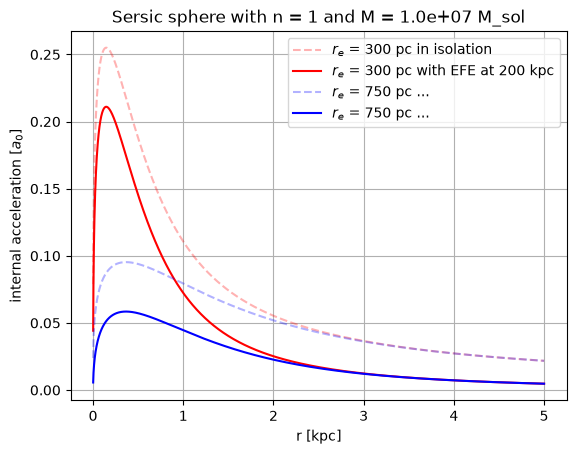

In [3]:
M = 1e7
n = 1
r_e = 750
a_p = 10
r = np.linspace(1, 5000, 5000) #pc
mass_enc_3 = sersic_mass(r, M, n, r_e = 300)
mass_enc_7 = sersic_mass(r, M, n, r_e = 750)
#plt.plot(r/1e3, g_newton(r, mass_enc_s)/a0_kms_pc, c = "grey", ls = "dashed", label="Newtonian")
plt.plot(r/1e3, g_mond(r_pc_array = r, M_enc_array= mass_enc_3)/a0_kms_pc, c = "r", ls = "dashed", alpha = 0.3, label="$r_e$ = 300 pc in isolation")
plt.plot(r/1e3, g_mond_efe(r_pc_array = r, M_enc_array = mass_enc_3, R_kpc = 200, M_host = 8.4e10)/a0_kms_pc, c = "r", label="$r_e$ = 300 pc with EFE at 200 kpc")
plt.plot(r/1e3, g_mond(r_pc_array = r, M_enc_array= mass_enc_7)/a0_kms_pc, c = "b", ls = "dashed", alpha = 0.3, label="$r_e$ = 750 pc ...")
plt.plot(r/1e3, g_mond_efe(r_pc_array = r, M_enc_array = mass_enc_7, R_kpc = 200, M_host = 8.4e10)/a0_kms_pc,c = "b", label="$r_e$ = 750 pc ...")
plt.xlabel("r [kpc]")
plt.ylabel("internal acceleration [$a_0$]")
plt.title(f"Sersic sphere with n = {n} and M = {M:.1e} M_sol")
plt.legend()
plt.grid(True)

In [4]:
def mond_potential_bound(r_array, mass_enc_array, n_ext=200):
    """
    Potential for bound mass calculation. 
    """
    r_array        = np.maximum(np.asarray(r_array, dtype=float), 1.0)
    r_max = np.max(r_array)
    mass_enc_array = np.asarray(mass_enc_array, dtype=float)
    
    r_cutoff =  r_max * 1000
    M_tot = mass_enc_array[-1]

    r_tail   = np.geomspace(r_max, r_cutoff, n_ext)
    g_tail   = g_mond(r_tail, M_tot)
    phi_tail = cumulative_trapezoid(g_tail, r_tail, initial=0)
    total_tail = phi_tail[-1]
    phi_tail   = phi_tail - total_tail  

    g_tail   = g_mond(r_tail, M_tot)
    g_arr = g_mond(r_array, mass_enc_array)
    
    phi   = cumulative_trapezoid(g_arr[::-1], r_array[::-1], initial=0)[::-1]
    phi_tail = cumulative_trapezoid(g_tail[::-1], r_tail[::-1], initial=0)[::-1]
    
    phi += phi_tail[0]
    
    return phi

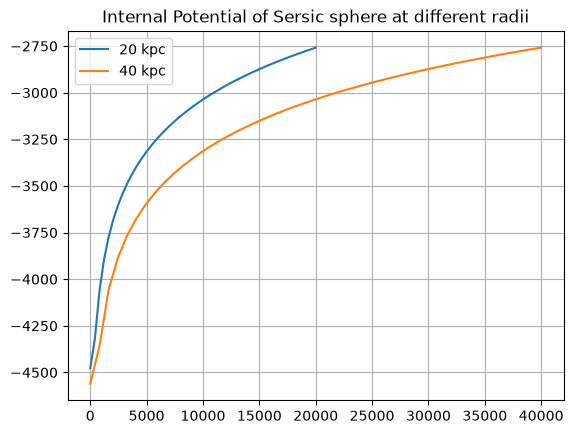

In [5]:
r_2 = np.linspace(0.01,20000)
r_4 = np.linspace(0.01,40000)
m_enc_2 = sersic_mass(r_2, 1e7, 1, 300)
m_enc_4 = sersic_mass(r_4, 1e7, 1, 300)
plt.plot(r_2, mond_potential_bound(r_2, m_enc_2), label="20 kpc")
plt.plot(r_4, mond_potential_bound(r_4, m_enc_4), label="40 kpc")
plt.legend()
plt.grid(True)
plt.title("Internal Potential of Sersic sphere at different radii")
plt.show()

In [14]:
R = 200
M_host = 9.15e10
pos, vel, mass, r, sigma = get_dwarf(profile="sersic", mond= True, r_e = 300, n = 1,  N= 100000, M = 1e7, r_max = 6, R = R, M_host = M_host, efe = False)
r0 = [100.0, 0.0, 0.0]
v0 = [0.0, 200.4, 0.0]
write_ramses_txt("sersic_0.3_1e5.txt", pos + r0, vel + v0, mass)
write_ramses_txt("sersic_initial.txt", pos, vel, mass)

Set up Positions...
Inverting cummulative mass ...
Positions set up!
Solve for velocities ...
Velocities set up!
N particles     : 100000
Total mass      : 1.000e+07 Msun
Max radius      : 3.04 kpc
Mean speed      : 15.58 km/s
Mean sigma     : 9.77 km/s
Virial ratio 0.9982962463510436
Dwarf in virial equilibrium! Congrats!
Written 100000 particles to sersic_0.3_1e5.txt
Written 100000 particles to sersic_initial.txt


/var/folders/n1/wqp51b41733bm3stn84s07h40000gn/T/ipykernel_63886/1097098702.py:402: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space at top for suptitle
/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


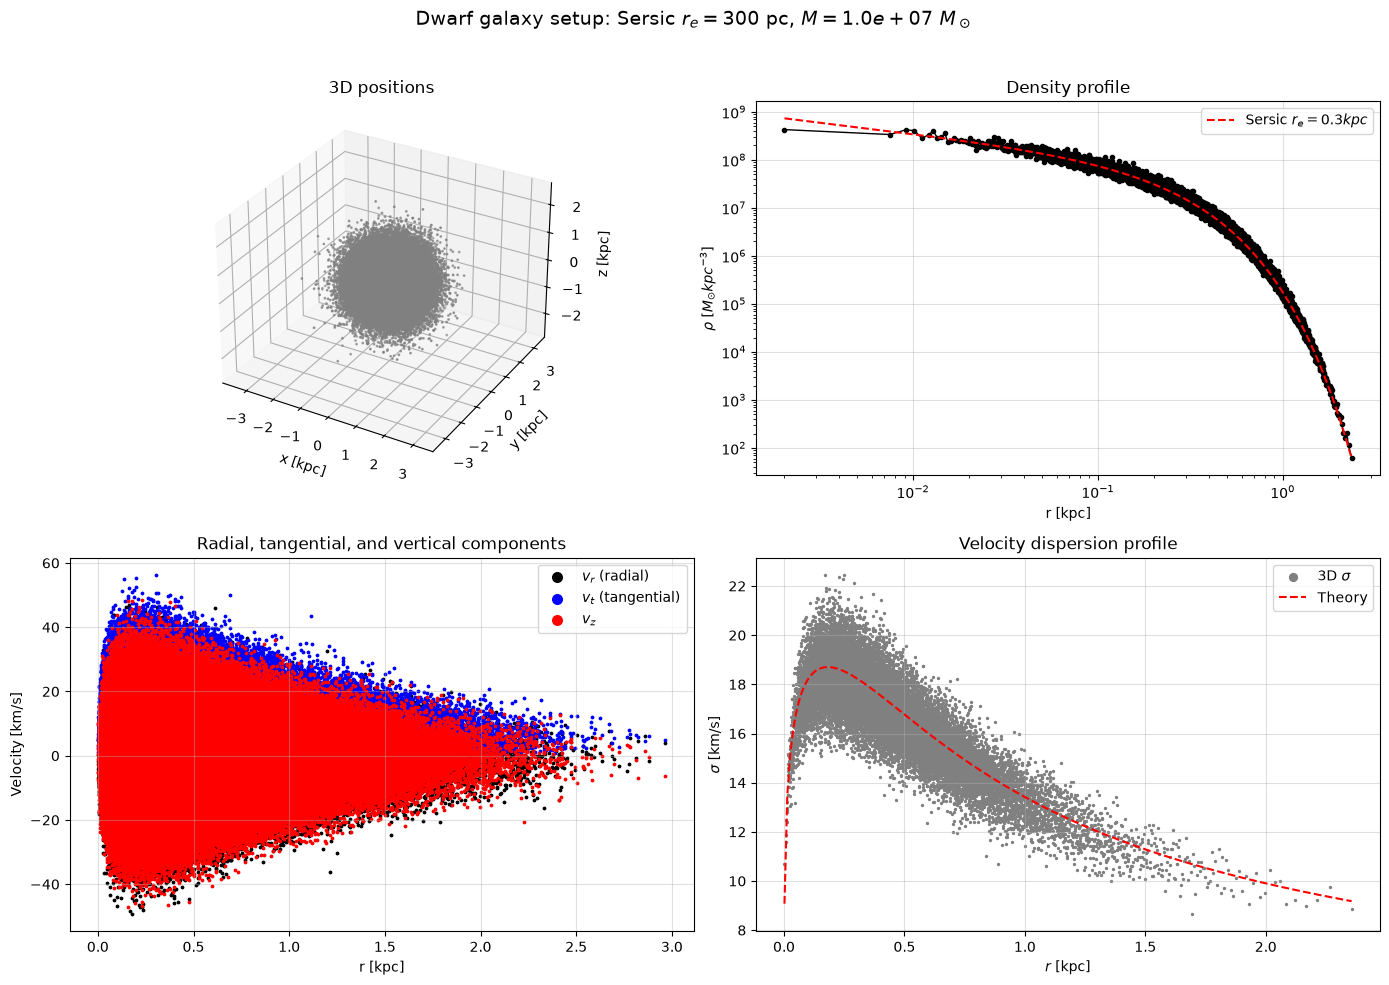

([np.float64(0.002018011239912194),
  np.float64(0.00749520154968537),
  np.float64(0.009133606944595779),
  np.float64(0.010173993388907733),
  np.float64(0.011206612528778338),
  np.float64(0.012175640329278129),
  np.float64(0.01287654420390383),
  np.float64(0.013551753591786463),
  np.float64(0.014260871114482383),
  np.float64(0.014844881335040418),
  np.float64(0.01545051127988106),
  np.float64(0.016117059519592674),
  np.float64(0.01667353884398147),
  np.float64(0.017182820405439336),
  np.float64(0.017701624528899812),
  np.float64(0.018193571111344356),
  np.float64(0.018664290140111416),
  np.float64(0.01912045799296591),
  np.float64(0.01955935181319712),
  np.float64(0.019992786411789955),
  np.float64(0.020376160998174984),
  np.float64(0.020758026685861096),
  np.float64(0.02115462502091123),
  np.float64(0.021548863530217496),
  np.float64(0.022014749072864347),
  np.float64(0.02242514494222325),
  np.float64(0.022791752168478684),
  np.float64(0.023188289361018775),


In [12]:
plot_setup("sersic_initial.txt", R = 200, M = 1e7, n = 1, r_e = 300)

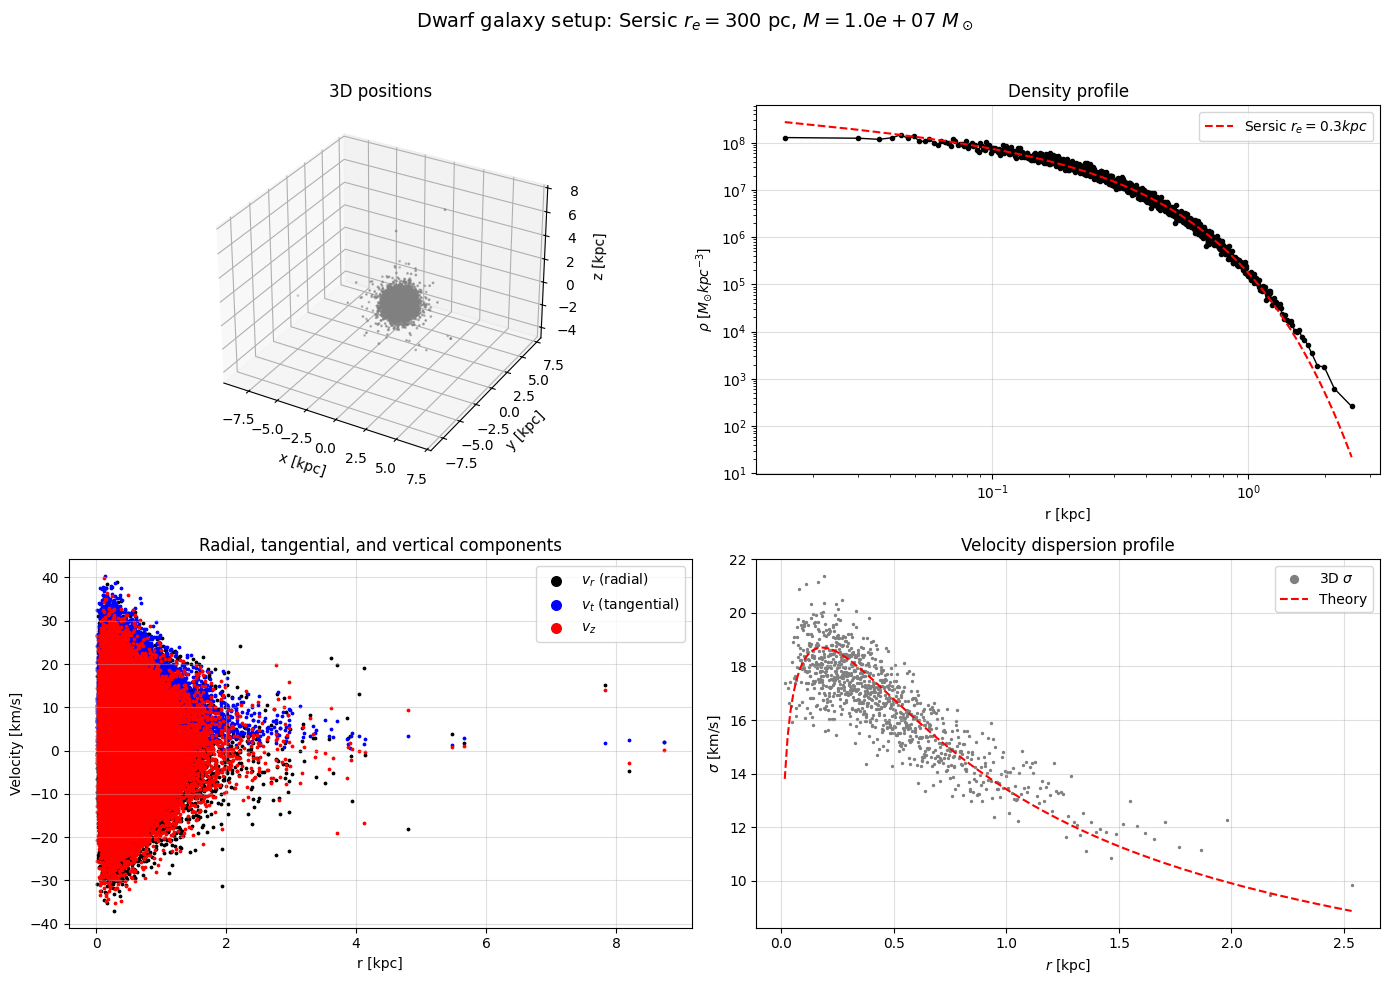

([np.float64(0.015505188109070981),
  np.float64(0.03007437734393528),
  np.float64(0.03620545260179369),
  np.float64(0.040684312074075066),
  np.float64(0.04397459315307046),
  np.float64(0.04682272269148518),
  np.float64(0.04948463195331739),
  np.float64(0.05203918195727265),
  np.float64(0.05465064719178741),
  np.float64(0.056906160329898876),
  np.float64(0.059052636765404766),
  np.float64(0.061357557637262576),
  np.float64(0.06342296053388412),
  np.float64(0.06523550505710823),
  np.float64(0.06702489459599073),
  np.float64(0.06887175946758033),
  np.float64(0.07050705785483731),
  np.float64(0.0718724285198437),
  np.float64(0.07341788494438546),
  np.float64(0.07500249108871788),
  np.float64(0.07645657626154737),
  np.float64(0.07791769150905196),
  np.float64(0.07925103170692181),
  np.float64(0.08061719529285133),
  np.float64(0.0820774764482312),
  np.float64(0.08333139476695414),
  np.float64(0.08457053958418857),
  np.float64(0.08582812674408268),
  np.float64(0.08

In [ ]:
plot_setup("sers_0.3_equ.txt", R = 200, M = 1e7, n = 1, r_e = 300)